# Chapter 14: learning to write like Shakespeare: long short-term memory

Haikal Ali TK-46-GAB 1103223071

## In this chapter

- Character language modeling
- Truncated backpropagation
- Vanishing and exploding gradients
- A toy example of RNN backpropagation
- Long short-term memory (LSTM) cells

## Setup framework dependency

Chapter ini memakai framework kecil dari chapter sebelumnya: `Tensor`, autograd, `SGD`, layer abstraction, `Embedding`, `CrossEntropyLoss`, dan `RNNCell`. Cell berikut menyiapkan dependency tersebut agar kode chapter ini bisa langsung dijalankan di Colab.

In [1]:
import sys
import random
import math
from collections import Counter
from pathlib import Path

import numpy as np

np.random.seed(0)

class Tensor(object):
  def __init__(
    self,
    data,
    autograd=False,
    creators=None,
    creation_op=None,
    id=None
  ):
    self.data = np.array(data)
    self.creators = creators
    self.creation_op = creation_op
    self.grad = None
    self.autograd = autograd
    self.children = {}

    if id is None:
      id = np.random.randint(0, 100000)

    self.id = id

    if creators is not None:
      for c in creators:
        if self.id not in c.children:
          c.children[self.id] = 1
        else:
          c.children[self.id] += 1

  def all_children_grads_accounted_for(self):
    for id, cnt in self.children.items():
      if cnt != 0:
        return False

    return True

  def backward(self, grad=None, grad_origin=None):
    if not self.autograd:
      return

    if grad is None:
      grad = Tensor(np.ones_like(self.data))

    if grad_origin is not None:
      if self.children[grad_origin.id] == 0:
        raise Exception("cannot backprop more than once")
      else:
        self.children[grad_origin.id] -= 1

    if self.grad is None:
      self.grad = grad
    else:
      self.grad += grad

    if self.creators is not None and (
      self.all_children_grads_accounted_for() or grad_origin is None
    ):
      if self.creation_op == "add":
        self.creators[0].backward(self.grad, self)
        self.creators[1].backward(self.grad, self)

      if self.creation_op == "neg":
        self.creators[0].backward(self.grad.__neg__(), self)

      if self.creation_op == "sub":
        self.creators[0].backward(Tensor(self.grad.data), self)
        self.creators[1].backward(Tensor(self.grad.__neg__().data), self)

      if self.creation_op == "mul":
        self.creators[0].backward(self.grad * self.creators[1], self)
        self.creators[1].backward(self.grad * self.creators[0], self)

      if self.creation_op == "mm":
        act = self.creators[0]
        weights = self.creators[1]

        act.backward(self.grad.mm(weights.transpose()), self)
        weights.backward(self.grad.transpose().mm(act).transpose(), self)

      if self.creation_op == "transpose":
        self.creators[0].backward(self.grad.transpose(), self)

      if self.creation_op is not None and "sum" in self.creation_op:
        dim = int(self.creation_op.split("_")[1])
        ds = self.creators[0].data.shape[dim]
        self.creators[0].backward(self.grad.expand(dim, ds), self)

      if self.creation_op is not None and "expand" in self.creation_op:
        dim = int(self.creation_op.split("_")[1])
        self.creators[0].backward(self.grad.sum(dim), self)

      if self.creation_op == "sigmoid":
        ones = Tensor(np.ones_like(self.grad.data))
        self.creators[0].backward(self.grad * (self * (ones - self)), self)

      if self.creation_op == "tanh":
        ones = Tensor(np.ones_like(self.grad.data))
        self.creators[0].backward(self.grad * (ones - (self * self)), self)

      if self.creation_op == "index_select":
        new_grad = np.zeros_like(self.creators[0].data)
        indices_ = self.index_select_indices.data.flatten()
        grad_ = self.grad.data.reshape(len(indices_), -1)

        for i in range(len(indices_)):
          new_grad[indices_[i]] += grad_[i]

        self.creators[0].backward(Tensor(new_grad), self)

      if self.creation_op == "cross_entropy":
        dx = self.softmax_output - self.target_dist
        self.creators[0].backward(Tensor(dx), self)

  def __add__(self, other):
    if self.autograd and other.autograd:
      return Tensor(
        self.data + other.data,
        autograd=True,
        creators=[self, other],
        creation_op="add"
      )

    return Tensor(self.data + other.data)

  def __neg__(self):
    if self.autograd:
      return Tensor(
        self.data * -1,
        autograd=True,
        creators=[self],
        creation_op="neg"
      )

    return Tensor(self.data * -1)

  def __sub__(self, other):
    if self.autograd and other.autograd:
      return Tensor(
        self.data - other.data,
        autograd=True,
        creators=[self, other],
        creation_op="sub"
      )

    return Tensor(self.data - other.data)

  def __mul__(self, other):
    if self.autograd and other.autograd:
      return Tensor(
        self.data * other.data,
        autograd=True,
        creators=[self, other],
        creation_op="mul"
      )

    return Tensor(self.data * other.data)

  def sum(self, dim):
    if self.autograd:
      return Tensor(
        self.data.sum(dim),
        autograd=True,
        creators=[self],
        creation_op="sum_" + str(dim)
      )

    return Tensor(self.data.sum(dim))

  def expand(self, dim, copies):
    trans_cmd = list(range(0, len(self.data.shape)))
    trans_cmd.insert(dim, len(self.data.shape))

    new_shape = list(self.data.shape) + [copies]
    new_data = self.data.repeat(copies).reshape(new_shape)
    new_data = new_data.transpose(trans_cmd)

    if self.autograd:
      return Tensor(
        new_data,
        autograd=True,
        creators=[self],
        creation_op="expand_" + str(dim)
      )

    return Tensor(new_data)

  def transpose(self):
    if self.autograd:
      return Tensor(
        self.data.transpose(),
        autograd=True,
        creators=[self],
        creation_op="transpose"
      )

    return Tensor(self.data.transpose())

  def mm(self, x):
    if self.autograd:
      return Tensor(
        self.data.dot(x.data),
        autograd=True,
        creators=[self, x],
        creation_op="mm"
      )

    return Tensor(self.data.dot(x.data))

  def sigmoid(self):
    if self.autograd:
      return Tensor(
        1 / (1 + np.exp(-self.data)),
        autograd=True,
        creators=[self],
        creation_op="sigmoid"
      )

    return Tensor(1 / (1 + np.exp(-self.data)))

  def tanh(self):
    if self.autograd:
      return Tensor(
        np.tanh(self.data),
        autograd=True,
        creators=[self],
        creation_op="tanh"
      )

    return Tensor(np.tanh(self.data))

  def softmax(self):
    temp = np.exp(self.data - np.max(self.data, axis=len(self.data.shape) - 1, keepdims=True))
    return temp / np.sum(temp, axis=len(self.data.shape) - 1, keepdims=True)

  def index_select(self, indices):
    if self.autograd:
      new = Tensor(
        self.data[indices.data],
        autograd=True,
        creators=[self],
        creation_op="index_select"
      )
      new.index_select_indices = indices
      return new

    return Tensor(self.data[indices.data])

  def cross_entropy(self, target_indices):
    temp = np.exp(self.data - np.max(self.data, axis=len(self.data.shape) - 1, keepdims=True))
    softmax_output = temp / np.sum(temp, axis=len(self.data.shape) - 1, keepdims=True)

    t = target_indices.data.flatten()
    p = softmax_output.reshape(len(t), -1)
    target_dist = np.eye(p.shape[1])[t]

    loss = -(np.log(p + 1e-12) * target_dist).sum(1).mean()

    if self.autograd:
      out = Tensor(
        loss,
        autograd=True,
        creators=[self],
        creation_op="cross_entropy"
      )
      out.softmax_output = softmax_output
      out.target_dist = target_dist
      return out

    return Tensor(loss)

  def __repr__(self):
    return str(self.data.__repr__())

  def __str__(self):
    return str(self.data.__str__())


class SGD(object):
  def __init__(self, parameters, alpha=0.1):
    self.parameters = parameters
    self.alpha = alpha

  def zero(self):
    for p in self.parameters:
      if p.grad is not None:
        p.grad.data *= 0

  def step(self, zero=True):
    for p in self.parameters:
      if p.grad is None:
        continue

      p.data -= p.grad.data * self.alpha

      if zero:
        p.grad.data *= 0


class Layer(object):
  def __init__(self):
    self.parameters = []

  def get_parameters(self):
    return self.parameters


class Linear(Layer):
  def __init__(self, n_inputs, n_outputs, bias=True):
    super().__init__()

    W = np.random.randn(n_inputs, n_outputs) * np.sqrt(2.0 / n_inputs)

    self.weight = Tensor(W, autograd=True)
    self.parameters.append(self.weight)

    self.use_bias = bias

    if bias:
      self.bias = Tensor(np.zeros(n_outputs), autograd=True)
      self.parameters.append(self.bias)
    else:
      self.bias = None

  def forward(self, input):
    output = input.mm(self.weight)

    if self.use_bias:
      output = output + self.bias.expand(0, len(input.data))

    return output


class Sequential(Layer):
  def __init__(self, layers=[]):
    super().__init__()
    self.layers = layers

  def add(self, layer):
    self.layers.append(layer)

  def forward(self, input):
    for layer in self.layers:
      input = layer.forward(input)

    return input

  def get_parameters(self):
    params = []

    for layer in self.layers:
      params += layer.get_parameters()

    return params


class Tanh(Layer):
  def __init__(self):
    super().__init__()

  def forward(self, input):
    return input.tanh()


class Sigmoid(Layer):
  def __init__(self):
    super().__init__()

  def forward(self, input):
    return input.sigmoid()


class Embedding(Layer):
  def __init__(self, vocab_size, dim):
    super().__init__()

    self.vocab_size = vocab_size
    self.dim = dim

    weight = (np.random.rand(vocab_size, dim) - 0.5) / dim
    self.weight = Tensor(weight, autograd=True)
    self.parameters.append(self.weight)

  def forward(self, input):
    return self.weight.index_select(input)


class CrossEntropyLoss(object):
  def __init__(self):
    super().__init__()

  def forward(self, input, target):
    return input.cross_entropy(target)


class RNNCell(Layer):
  def __init__(self, n_inputs, n_hidden, n_output, activation="sigmoid"):
    super().__init__()

    self.n_inputs = n_inputs
    self.n_hidden = n_hidden
    self.n_output = n_output

    if activation == "sigmoid":
      self.activation = Sigmoid()
    elif activation == "tanh":
      self.activation = Tanh()
    else:
      raise Exception("Non-linearity not found")

    self.w_ih = Linear(n_inputs, n_hidden)
    self.w_hh = Linear(n_hidden, n_hidden)
    self.w_ho = Linear(n_hidden, n_output)

    self.parameters += self.w_ih.get_parameters()
    self.parameters += self.w_hh.get_parameters()
    self.parameters += self.w_ho.get_parameters()

  def forward(self, input, hidden):
    from_prev_hidden = self.w_hh.forward(hidden)
    combined = self.w_ih.forward(input) + from_prev_hidden
    new_hidden = self.activation.forward(combined)
    output = self.w_ho.forward(new_hidden)

    return output, new_hidden

  def init_hidden(self, batch_size=1):
    return Tensor(np.zeros((batch_size, self.n_hidden)), autograd=True)

## Character language modeling

Chapter ini memakai task yang lebih sulit daripada toy dataset pada chapter sebelumnya: language modeling pada karya Shakespeare.

Model tidak lagi memprediksi next word dari previous words, tetapi memprediksi **next character** dari previous characters. Vocabulary sekarang berisi characters, bukan words.

In [2]:
from pathlib import Path

shakespeare_path = Path("shakespear.txt")

if not shakespeare_path.exists():
  # File di buku bernama shakespear.txt. Cell ini mengunduh teks Shakespeare agar notebook bisa langsung dijalankan di Colab.
  !wget -q -O shakespear.txt https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

if not shakespeare_path.exists():
  raise FileNotFoundError("shakespear.txt belum ditemukan.")

with open(shakespeare_path, "r", encoding="utf-8") as f:
  raw = f.read()

vocab = list(set(raw))
word2index = {}

for i, word in enumerate(vocab):
  word2index[word] = i

indices = np.array(list(map(lambda x: word2index[x], raw)))

print("Jumlah karakter:", len(raw))
print("Ukuran vocab:", len(vocab))
print("Contoh raw:", raw[0:50])
print("Contoh indices:", indices[0:10])

Jumlah karakter: 1115394
Ukuran vocab: 65
Contoh raw: First Citizen:
Before we proceed any further, hear
Contoh indices: [56 18 59  3 30 36  2 18 30 18]


Di chapter sebelumnya, vocabulary berisi words. Pada chapter ini, vocabulary berisi characters dalam dataset. Seluruh text diubah menjadi array indices karakter.

Kode setup model RNN dari buku:

In [3]:
np.random.seed(0)

embed = Embedding(vocab_size=len(vocab), dim=512)
model = RNNCell(n_inputs=512, n_hidden=512, n_output=len(vocab))

criterion = CrossEntropyLoss()
optim = SGD(
  parameters=model.get_parameters() + embed.get_parameters(),
  alpha=0.05
)

print("Embedding params:", embed.weight.data.shape)
print("Hidden size:", model.n_hidden)
print("Output size:", model.n_output)

Embedding params: (65, 512)
Hidden size: 512
Output size: 65


Pada buku, embedding dimensionality dan hidden state size dipakai besar. Untuk cell training runnable di Colab free tier, bagian training berikutnya menyediakan versi ringan. Struktur training tetap sama.

## The need for truncated backpropagation

Backpropagating melalui 100.000 characters tidak praktis.

Pada RNN chapter sebelumnya, network hanya membaca lima words lalu memprediksi word keenam. Karena sequence pendek, `loss.backward()` dapat backpropagate sampai ke awal sequence.

Pada Shakespeare dataset, sequence sangat panjang. Backpropagation ke seluruh text untuk setiap prediction terlalu berat. Solusinya adalah **truncated backpropagation**, yaitu backpropagate hanya sejumlah timestep tetap ke masa lalu, lalu berhenti.

## Truncated backpropagation

Truncated backpropagation memang memperlemah kemampuan teoritis network untuk mengingat informasi yang sangat jauh di masa lalu. Namun, ini adalah standar industri untuk RNN.

Untuk language modeling, panjang truncation disebut `bptt`, biasanya berada antara 16 sampai 64. Chapter ini menunjukkan batching logic untuk mengubah sequence panjang menjadi banyak potongan sequence kecil sepanjang `bptt`.

In [4]:
batch_size = 32
bptt = 16

n_batches = int((indices.shape[0] / batch_size))

trimmed_indices = indices[:n_batches * batch_size]
batched_indices = trimmed_indices.reshape(batch_size, n_batches)
batched_indices = batched_indices.transpose()

input_batched_indices = batched_indices[0:-1]
target_batched_indices = batched_indices[1:]

n_bptt = int(((n_batches - 1) / bptt))

input_batches = input_batched_indices[:n_bptt * bptt]
input_batches = input_batches.reshape(n_bptt, bptt, batch_size)

target_batches = target_batched_indices[:n_bptt * bptt]
target_batches = target_batches.reshape(n_bptt, bptt, batch_size)

print(raw[0:5])
print(indices[0:5])
print("batched_indices shape:", batched_indices.shape)
print("input_batches shape:", input_batches.shape)
print("target_batches shape:", target_batches.shape)

First
[56 18 59  3 30]
batched_indices shape: (34856, 32)
input_batches shape: (2178, 16, 32)
target_batches shape: (2178, 16, 32)


`target_batches` adalah `input_batches` yang digeser satu character ke depan. Dengan begitu, pada setiap timestep network belajar memprediksi next character.

Kode berikut menunjukkan truncated backpropagation pada RNN. Untuk Colab free tier, model dibuat lebih kecil dan training default hanya satu iteration. Struktur training mengikuti chapter: membaca `bptt` steps, menjumlahkan loss, backward, lalu update weights.

In [5]:
np.random.seed(0)

# Versi ringan agar runnable di Colab free tier.
embed = Embedding(vocab_size=len(vocab), dim=32)
model = RNNCell(n_inputs=32, n_hidden=32, n_output=len(vocab))

criterion = CrossEntropyLoss()
optim = SGD(
  parameters=model.get_parameters() + embed.get_parameters(),
  alpha=0.05
)

batch_size = 8
bptt = 16

n_batches = int((indices.shape[0] / batch_size))
trimmed_indices = indices[:n_batches * batch_size]
batched_indices = trimmed_indices.reshape(batch_size, n_batches).transpose()

input_batched_indices = batched_indices[0:-1]
target_batched_indices = batched_indices[1:]

n_bptt = int(((n_batches - 1) / bptt))

# Batasi jumlah batch agar cepat di-run.
max_bptt_batches = min(20, n_bptt)

input_batches = input_batched_indices[:max_bptt_batches * bptt]
input_batches = input_batches.reshape(max_bptt_batches, bptt, batch_size)

target_batches = target_batched_indices[:max_bptt_batches * bptt]
target_batches = target_batches.reshape(max_bptt_batches, bptt, batch_size)

def generate_sample(n=30, init_char=" "):
  s = ""
  hidden = model.init_hidden(batch_size=1)
  input = Tensor(np.array([word2index[init_char]]), autograd=True)

  for i in range(n):
    rnn_input = embed.forward(input)
    output, hidden = model.forward(input=rnn_input, hidden=hidden)

    output.data *= 10
    temp_dist = output.softmax()
    temp_dist /= temp_dist.sum()

    m = (temp_dist > np.random.rand()).argmax()
    c = vocab[m]

    input = Tensor(np.array([m]), autograd=True)
    s += c

  return s

def train(iterations=1):
  for iter in range(iterations):
    total_loss = 0
    hidden = model.init_hidden(batch_size=batch_size)

    for batch_i in range(len(input_batches)):
      hidden = Tensor(hidden.data, autograd=True)
      losses = []
      loss = None

      for t in range(bptt):
        input = Tensor(input_batches[batch_i][t], autograd=True)
        rnn_input = embed.forward(input=input)

        output, hidden = model.forward(input=rnn_input, hidden=hidden)

        target = Tensor(target_batches[batch_i][t], autograd=True)
        batch_loss = criterion.forward(output, target)

        losses.append(batch_loss)

        if t == 0:
          loss = batch_loss
        else:
          loss = loss + batch_loss

      loss.backward()
      optim.step()

      total_loss += loss.data / bptt

      log = "\r Iter:" + str(iter)
      log += " - Batch " + str(batch_i + 1) + "/" + str(len(input_batches))
      log += " - Loss:" + str(np.exp(total_loss / (batch_i + 1)))

      if batch_i == 0:
        log += " - " + generate_sample(70, "\n").replace("\n", " ")

      if batch_i % 5 == 0 or batch_i + 1 == len(input_batches):
        sys.stdout.write(log)

    optim.alpha *= 0.99
    print()

train(iterations=1)

 Iter:0 - Batch 20/20 - Loss:50.30886577551505


## A sample of the output

Sampling dilakukan dengan mengambil prediction model, mengubahnya menjadi distribution, lalu memilih karakter berikutnya dari distribution tersebut.

Pada awal training, output masih kacau. Setelah training lama, output mulai terlihat seperti gaya Shakespeare.

In [6]:
print(generate_sample(n=200, init_char="\n"))

e e Ge e e e e e e e Ge e e e e e e e e Ge e e e Ge e e e e e e e e e e Ge Ge e e e e e e e e e e e e Ge Ge e e e e e e e e Ge e Ge e e e e e e Ge e e Ge e e e e e e e Ge e e e Ge e e e e e e e Ge e e


## Vanishing and exploding gradients

Vanilla RNN mengalami vanishing dan exploding gradients.

Pada RNN, hidden state diperbarui berulang kali dengan matrix multiplication dan nonlinearity. Forward propagation relatif stabil karena nonlinearity seperti sigmoid membatasi nilai hidden state. Namun, backpropagation tidak memiliki properti stabil yang sama.

Gradient dapat menjadi sangat besar karena matrix multiplication berulang, atau menjadi sangat kecil karena derivative sigmoid sangat kecil di bagian tail.

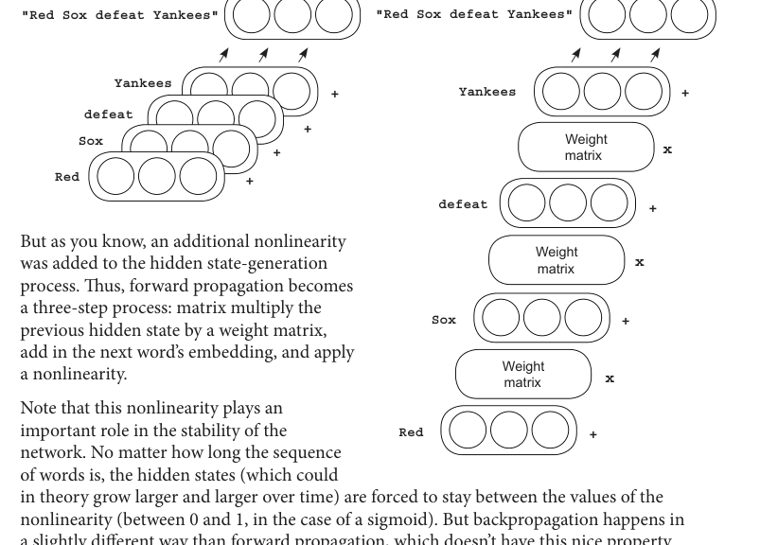

## A toy example of RNN backpropagation

Kode berikut menunjukkan gradient yang menghilang pada sigmoid dan gradient yang meledak pada relu.

In [7]:
sigmoid = lambda x: 1 / (1 + np.exp(-x))
relu = lambda x: (x > 0).astype(float) * x

weights = np.array([
  [1, 4],
  [4, 1]
])

activation = sigmoid(np.array([1, 0.01]))

print("Sigmoid Activations")

activations = []

for iter in range(10):
  activation = sigmoid(activation.dot(weights))
  activations.append(activation)
  print(activation)

print("\nSigmoid Gradients")

gradient = np.ones_like(activation)

for activation in reversed(activations):
  gradient = activation * (1 - activation) * gradient
  gradient = gradient.dot(weights.transpose())
  print(gradient)

print("\nRelu Activations")

activations = []

for iter in range(10):
  activation = relu(activation.dot(weights))
  activations.append(activation)
  print(activation)

print("\nRelu Gradients")

gradient = np.ones_like(activation)

for activation in reversed(activations):
  gradient = ((activation > 0) * gradient).dot(weights.transpose())
  print(gradient)

Sigmoid Activations
[0.93940638 0.96852968]
[0.9919462  0.99121735]
[0.99301385 0.99302901]
[0.9930713  0.99307098]
[0.99307285 0.99307285]
[0.99307291 0.99307291]
[0.99307291 0.99307291]
[0.99307291 0.99307291]
[0.99307291 0.99307291]
[0.99307291 0.99307291]

Sigmoid Gradients
[0.03439552 0.03439552]
[0.00118305 0.00118305]
[4.06916726e-05 4.06916726e-05]
[1.39961115e-06 1.39961115e-06]
[4.81403643e-08 4.81403637e-08]
[1.65582672e-09 1.65582765e-09]
[5.69682675e-11 5.69667160e-11]
[1.97259346e-12 1.97517920e-12]
[8.45387597e-14 8.02306381e-14]
[1.45938177e-14 2.16938983e-14]

Relu Activations
[4.8135251  4.72615519]
[23.71814585 23.98025559]
[119.63916823 118.852839  ]
[595.05052421 597.40951192]
[2984.68857188 2977.61160877]
[14895.13500696 14916.36589628]
[74560.59859209 74496.90592414]
[372548.22228863 372739.30029248]
[1863505.42345854 1862932.18944699]
[9315234.18124649 9316953.88328115]

Relu Gradients
[5. 5.]
[25. 25.]
[125. 125.]
[625. 625.]
[3125. 3125.]
[15625. 15625.]
[7812

Sigmoid menghasilkan gradients yang sangat kecil karena derivative-nya kecil ketika activation mendekati 0 atau 1. Relu pada contoh ini menghasilkan gradients yang sangat besar karena matrix multiplication berulang tidak “ditekan” oleh nonlinearity yang membatasi nilai.

## Long short-term memory (LSTM) cells

LSTM adalah model standar untuk melawan vanishing dan exploding gradients pada RNN.

Masalah utama vanilla RNN adalah hidden state berikutnya dibuat dengan matrix multiplication dan nonlinearity. LSTM menggunakan trik berbeda: hidden state utama atau `cell` diperbarui dengan proses copy, lalu informasi ditambahkan atau dihapus menggunakan gates.

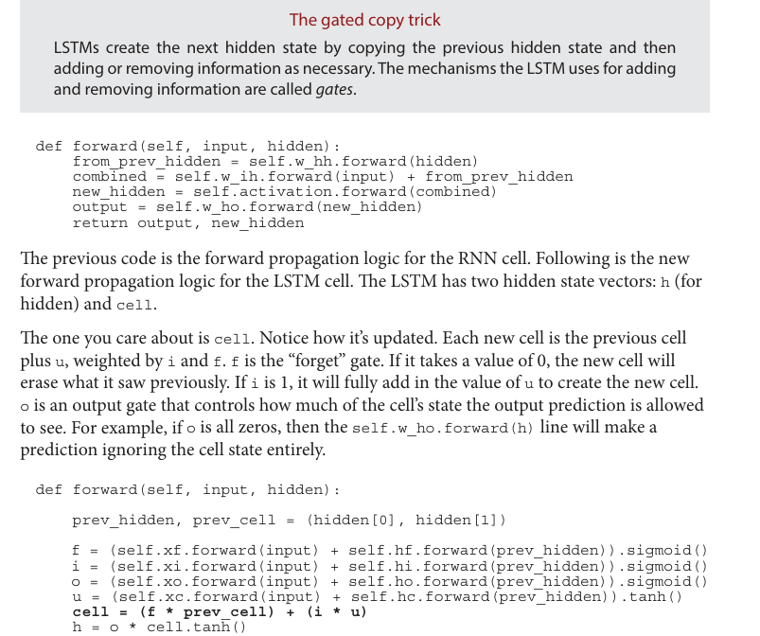

LSTM memiliki dua hidden state vectors:

- `h`: hidden state yang dipakai untuk prediction.
- `cell`: memory utama yang membawa informasi lintas timestep.

Gates dalam LSTM:

- `f`: forget gate, menentukan seberapa banyak previous cell dipertahankan.
- `i`: input gate, menentukan seberapa banyak update baru dimasukkan.
- `o`: output gate, menentukan seberapa banyak cell state terlihat pada hidden output.
- `g` atau `u`: candidate update vector.

## Some intuition about LSTM gates

Gates mirip dengan operasi membaca dan menulis memory.

Cell state diperbarui dengan:

`cell = (f * prev_cell) + (i * g)`

Jika `f` mendekati 1, informasi lama dipertahankan. Jika `f` mendekati 0, informasi lama dilupakan. Jika `i` mendekati 1, update baru dimasukkan. Jika `o` mendekati 0, prediction tidak melihat banyak isi cell.

Karena `cell` dapat dibawa dengan copy dan update, LSTM dapat menyimpan informasi jarak jauh tanpa selalu menerapkan matrix multiplication dan nonlinearity langsung pada cell.

## The long short-term memory layer

Kode berikut membuat `LSTMCell` menggunakan autograd framework.

In [8]:
class LSTMCell(Layer):
  def __init__(self, n_inputs, n_hidden, n_output):
    super().__init__()

    self.n_inputs = n_inputs
    self.n_hidden = n_hidden
    self.n_output = n_output

    self.xf = Linear(n_inputs, n_hidden)
    self.xi = Linear(n_inputs, n_hidden)
    self.xo = Linear(n_inputs, n_hidden)
    self.xc = Linear(n_inputs, n_hidden)

    self.hf = Linear(n_hidden, n_hidden, bias=False)
    self.hi = Linear(n_hidden, n_hidden, bias=False)
    self.ho = Linear(n_hidden, n_hidden, bias=False)
    self.hc = Linear(n_hidden, n_hidden, bias=False)

    self.w_ho = Linear(n_hidden, n_output, bias=False)

    self.parameters += self.xf.get_parameters()
    self.parameters += self.xi.get_parameters()
    self.parameters += self.xo.get_parameters()
    self.parameters += self.xc.get_parameters()

    self.parameters += self.hf.get_parameters()
    self.parameters += self.hi.get_parameters()
    self.parameters += self.ho.get_parameters()
    self.parameters += self.hc.get_parameters()

    self.parameters += self.w_ho.get_parameters()

  def forward(self, input, hidden):
    prev_hidden = hidden[0]
    prev_cell = hidden[1]

    f = (self.xf.forward(input) + self.hf.forward(prev_hidden)).sigmoid()
    i = (self.xi.forward(input) + self.hi.forward(prev_hidden)).sigmoid()
    o = (self.xo.forward(input) + self.ho.forward(prev_hidden)).sigmoid()

    g = (self.xc.forward(input) + self.hc.forward(prev_hidden)).tanh()

    c = (f * prev_cell) + (i * g)
    h = o * c.tanh()

    output = self.w_ho.forward(h)

    return output, (h, c)

  def init_hidden(self, batch_size=1):
    h = Tensor(np.zeros((batch_size, self.n_hidden)), autograd=True)
    c = Tensor(np.zeros((batch_size, self.n_hidden)), autograd=True)

    h.data[:, 0] += 1
    c.data[:, 0] += 1

    return (h, c)

## Upgrading the character language model

Untuk mengganti vanilla RNN menjadi LSTM, setup model berubah sedikit: `RNNCell` diganti menjadi `LSTMCell`.

Buku memakai `dim=512`, `n_hidden=512`, `batch_size=16`, dan `bptt=25`. Untuk Colab free tier, cell runnable di bawah memakai dimensi lebih kecil dan jumlah batch lebih sedikit.

In [9]:
np.random.seed(0)

# Versi ringan agar notebook bisa cepat dirun.
embed = Embedding(vocab_size=len(vocab), dim=32)
model = LSTMCell(n_inputs=32, n_hidden=32, n_output=len(vocab))

model.w_ho.weight.data *= 0

criterion = CrossEntropyLoss()
optim = SGD(
  parameters=model.get_parameters() + embed.get_parameters(),
  alpha=0.05
)

batch_size = 8
bptt = 16

n_batches = int((indices.shape[0] / batch_size))

trimmed_indices = indices[:n_batches * batch_size]
batched_indices = trimmed_indices.reshape(batch_size, n_batches).transpose()

input_batched_indices = batched_indices[0:-1]
target_batched_indices = batched_indices[1:]

n_bptt = int(((n_batches - 1) / bptt))
max_bptt_batches = min(20, n_bptt)

input_batches = input_batched_indices[:max_bptt_batches * bptt]
input_batches = input_batches.reshape(max_bptt_batches, bptt, batch_size)

target_batches = target_batched_indices[:max_bptt_batches * bptt]
target_batches = target_batches.reshape(max_bptt_batches, bptt, batch_size)

min_loss = 1000

print("input_batches:", input_batches.shape)
print("target_batches:", target_batches.shape)

input_batches: (20, 16, 8)
target_batches: (20, 16, 8)


## Training the LSTM character language model

Training logic hampir sama dengan vanilla RNN. Perbedaannya adalah hidden state sekarang terdiri dari dua vectors, yaitu `(h, c)`.

In [10]:
def generate_lstm_sample(n=30, init_char=" "):
  s = ""
  hidden = model.init_hidden(batch_size=1)
  input = Tensor(np.array([word2index[init_char]]), autograd=True)

  for i in range(n):
    rnn_input = embed.forward(input)
    output, hidden = model.forward(input=rnn_input, hidden=hidden)

    output.data *= 15
    temp_dist = output.softmax()
    temp_dist /= temp_dist.sum()

    # Sesuai kode buku bagian LSTM: mengambil max prediction.
    m = output.data.argmax()
    c = vocab[m]

    input = Tensor(np.array([m]), autograd=True)
    s += c

  return s

def train_lstm(iterations=1):
  global min_loss

  for iter in range(iterations):
    total_loss = 0
    hidden = model.init_hidden(batch_size=batch_size)

    batches_to_train = len(input_batches)

    for batch_i in range(batches_to_train):
      hidden = (
        Tensor(hidden[0].data, autograd=True),
        Tensor(hidden[1].data, autograd=True)
      )

      losses = []

      for t in range(bptt):
        input = Tensor(input_batches[batch_i][t], autograd=True)
        rnn_input = embed.forward(input=input)

        output, hidden = model.forward(input=rnn_input, hidden=hidden)

        target = Tensor(target_batches[batch_i][t], autograd=True)
        batch_loss = criterion.forward(output, target)

        if t == 0:
          losses.append(batch_loss)
        else:
          losses.append(batch_loss + losses[-1])

      loss = losses[-1]
      loss.backward()
      optim.step()

      total_loss += loss.data / bptt
      epoch_loss = np.exp(total_loss / (batch_i + 1))

      if epoch_loss < min_loss:
        min_loss = epoch_loss

      log = "\r Iter:" + str(iter)
      log += " - Alpha:" + str(optim.alpha)[0:5]
      log += " - Batch " + str(batch_i + 1) + "/" + str(len(input_batches))
      log += " - Min Loss:" + str(min_loss)[0:5]
      log += " - Loss:" + str(epoch_loss)

      if batch_i == 0:
        sample = generate_lstm_sample(n=70, init_char="T").replace("\n", " ")
        log += " - " + sample

      if batch_i % 5 == 0 or batch_i + 1 == len(input_batches):
        sys.stdout.write(log)

    optim.alpha *= 0.99
    print()

train_lstm(iterations=1)

 Iter:0 - Alpha:0.05 - Batch 20/20 - Min Loss:37.56 - Loss:37.56907081913074


## Tuning the LSTM character language model

Buku menyebut model ini membutuhkan tuning dan training lama. Training yang lebih lama biasanya menghasilkan output yang lebih baik, tetapi cell notebook ini dibuat ringan agar aman untuk Colab free tier.

In [11]:
print(generate_lstm_sample(n=500, init_char="\n"))

## Summary

LSTM adalah model yang kuat untuk sequence data.

Chapter ini menunjukkan character language modeling, truncated backpropagation, masalah vanishing dan exploding gradients, serta solusi LSTM. Vanilla RNN memperbarui hidden state dengan matrix multiplication dan nonlinearity, sehingga gradients dapat hilang atau meledak. LSTM menambahkan cell state dan gates agar informasi dapat disimpan, dilupakan, dan dibaca secara lebih stabil sepanjang sequence.

Dengan mengganti `RNNCell` menjadi `LSTMCell`, character language model dapat dilatih untuk menghasilkan teks bergaya Shakespeare.